# OPV light-intensity dependant JV fits with SIMsalabim and Lazy posterior analysis (real data)
This notebook is a demonstration of how to fit light-intensity dependent JV curves with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.

In [1]:
# Import necessary libraries
import warnings, os, sys, shutil
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import torch, copy, uuid
import pySIMsalabim as sim
from pySIMsalabim.experiments.JV_steady_state import *
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../..') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *

[INFO 04-27 17:38:22] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 04-27 17:38:22] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Get the experimental data

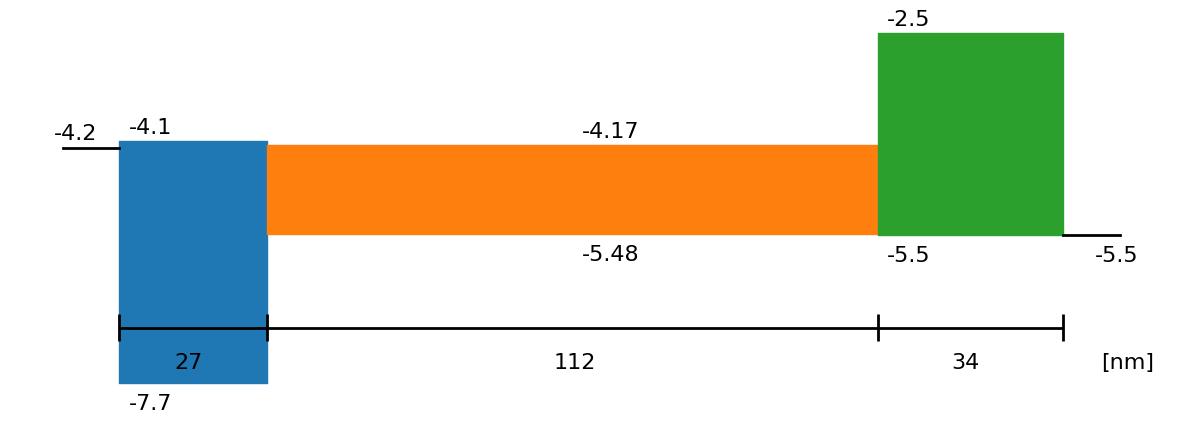

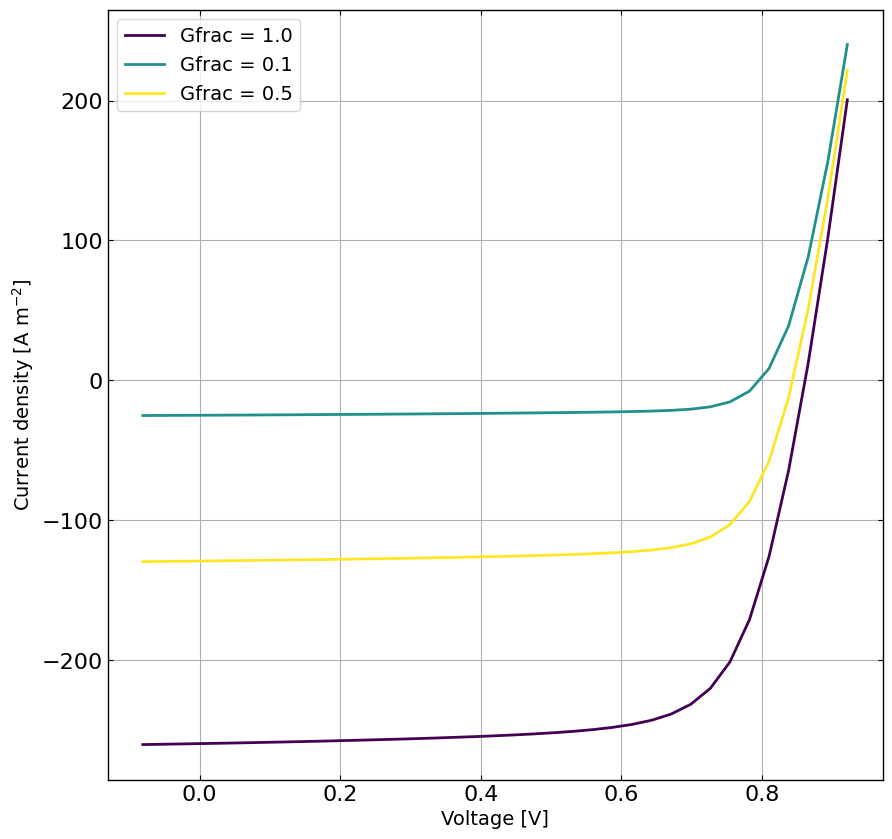

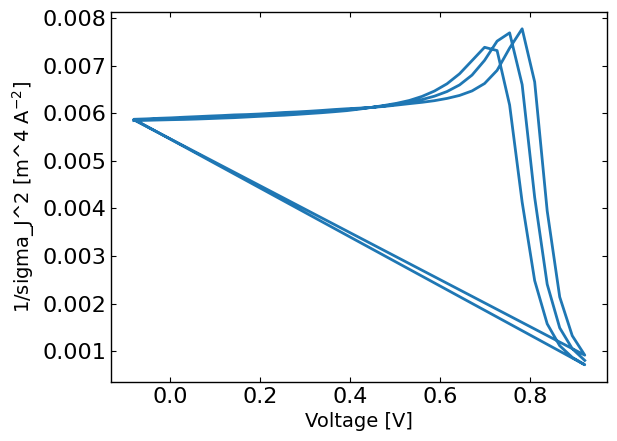

In [2]:
# Set the session path for the simulation and the input files
session_path = os.path.join(os.path.join(os.path.abspath('../..'),'SIMsalabim','SimSS'))
input_path = os.path.join(os.path.join(os.path.join(os.path.abspath('../..'),'Data','simsalabim_test_inputs','JVrealOPV')))
simulation_setup_filename = 'simulation_setup_PM6_L8BO.txt'
simulation_setup = os.path.join(session_path, simulation_setup_filename) 

# path to the layer files defined in the simulation_setup file
l1 = 'ZnO.txt'
l2 = 'PM6_L8BO.txt'
l3 = 'BM_HTL.txt'
l1 = os.path.join(input_path, l1 )
l2 = os.path.join(input_path, l2 )
l3 = os.path.join(input_path, l3 )

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path):
    os.makedirs(session_path)
for file in [l1,l2,l3,simulation_setup_filename]:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))
    else:
        print('File already exists: ',file)

# Show the device structure
fig = sim.plot_band_diagram(simulation_setup, session_path)
dev_par, layers = sim.load_device_parameters(session_path, simulation_setup, run_mode = False)
SIMsalabim_params  = {}
for layer in layers:
    SIMsalabim_params[layer[1]] = sim.ReadParameterFile(os.path.join(session_path,layer[2]))
L_active_Layer = float(SIMsalabim_params['l2']['L'])

# Load the JV data
df = pd.read_csv(os.path.join(input_path, 'JV_PM6_L8BO.dat'), sep=' ')
X = df[['Vext','Gfrac']].values
y = df[['Jext']].values.reshape(-1)
Gfracs = pd.unique(df['Gfrac'])
X_1sun = df[['Vext','Gfrac']].values[df['Gfrac'] == 1.0]
y_1sun = df[['Jext']].values[df['Gfrac'] == 1.0].reshape(-1)

# get 1sun Jsc as it will help narrow down the range for Gehp
Jsc_1sun = np.interp(0.0, X_1sun[:,0], y_1sun)
minJ = np.min(y_1sun)
q = constants.value(u'elementary charge')
G_ehp_calc = abs(Jsc_1sun/(q*L_active_Layer))
G_ehp_max = abs(minJ/(q*L_active_Layer))
# get Voc
Voc_1sun = np.interp(0.0, y_1sun, X_1sun[:,0])

# Filter some data
Vmin = -0.1
Jmax = abs(Jsc_1sun)
idx = np.where((X[:,0] > Vmin) & (y < Jmax))
y = y[idx]
X = X[idx]

# plot the data for each Gfrac
plt.figure(figsize=(10,10))
viridis = plt.get_cmap('viridis', len(Gfracs))
for i, Gfrac in enumerate(Gfracs):
    plt.plot(X[X[:,1] == Gfrac][:,0], y[X[:,1] == Gfrac], '-', label = f'Gfrac = {Gfrac}', color = viridis(i))
plt.grid()
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()

# calculate the sigma for the experimental data
std_phi = 0.05 # 5% error on light intensity
std_vol = 0.01 # 10 mV error on voltage

# reshape y such that each Gfrac is a column
y_reshaped = y.reshape((len(Gfracs), int(len(y)/len(Gfracs)))) # normalize to 10 A/m2
# print(y_reshaped)
# get dy/dGfrac
dJ_dphi = np.gradient(y_reshaped,Gfracs,axis=0,edge_order=2)  
dJ_dV = np.gradient(y_reshaped,X[:,0][X[:,1]==Gfracs[0]],axis=1,edge_order=2)

phi_term = (std_phi * dJ_dphi)**2
vol_term = (std_vol * dJ_dV)**2
phi_term = phi_term.flatten()
vol_term = vol_term.flatten()
sigma_J = np.sqrt((std_phi*dJ_dphi)**2 + (std_vol*dJ_dV)**2) 
# print((std_phi*dJ_dphi)**2, (std_vol*dJ_dV)**2)
# flatten sigma_J   
sigma_J = sigma_J.flatten()  # convert to absolute error

plt.figure()
plt.plot(X[:,0],1/sigma_J**2)
plt.xlabel('Voltage [V]')
plt.ylabel('1/sigma_J^2 [m^4 A$^{-2}$]')
plt.show()
plt.show()

## Define the parameters for the simulation

In [3]:
params = [] # list of parameters to be optimized

mun = FitParam(name = 'l2.mu_n', value = 7e-8, bounds = [5e-10,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 5e-8, bounds = [5e-10,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_p$', unit=r'm$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1e20, bounds = [1e17,1e22], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$N_{T}$', unit=r'm$^{-3}$', axis_type = 'log', force_log = True)
params.append(bulk_tr)

preLangevin = FitParam(name = 'l2.preLangevin', value = 1e-2, bounds = [1e-3,1], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\gamma_{pre}$', unit=r'', axis_type = 'log', force_log = True)
params.append(preLangevin)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-6,1e-2], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = True)
params.append(R_series)

R_shunt = FitParam(name = 'R_shunt', value = 1e1, bounds = [1e-2,1e2], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{shunt}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = True)
params.append(R_shunt)

G_ehp = FitParam(name = 'l2.G_ehp', value = G_ehp_calc, bounds = [G_ehp_calc*0.95,G_ehp_max*1.05], log_scale = False, value_type = 'float', fscale = None, rescale = False,  display_name=r'$G_{ehp}$', unit=r'm$^{-3}$ s$^{-1}$', axis_type = 'linear', force_log = False)
params.append(G_ehp)

# save the original parameters for later
params_orig = copy.deepcopy(params)

## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.models.DDfits.JVAgent import JVAgent
metric = 'mse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'
weight = 1/sigma_J**2

jv = JVAgent(params, X, y, session_path, simulation_setup, parallel = True, max_jobs = 3, metric = metric, loss = loss, weight = [weight])


In [5]:
# from optimpv.optimizers.BayesInfEmcee.EmceeOptimizer import EmceeOptimizer
from optimpv.optimizers.BayesInfUltraNest.UltraNestOptimizer import UltraNestOptimizer
# Define the Bayesian Inference object
optimizer = UltraNestOptimizer(
    params=params,
    agents=jv,
    progress=True,
    log_dir='ultranest_logs/jv',
    resume='subfolder', # can be True, False, 'subfolder', or 'overwrite'
    name='ultranest_jv',
    save_logs=False,
    run_kwargs={
        'min_num_live_points': 400,
        'min_ess': 100,
        'max_ncalls': 30000,
    },
)

In [6]:
res = optimizer.optimize()

[INFO 04-27 17:38:24] optimpv.UltraNestOptimizer: Running UltraNest nested sampling...


----------------------------------------------------

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1  2 [-8.7123..-6.6747] | it/evals=3777/30039 eff=12.7433% N=400             
[ultranest] Likelihood function evaluations: 30039
[ultranest] Reached maximum number of likelihood calls (30039 > 30000)...
[ultranest] done iterating.


[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: UltraNest run complete.
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $\mu_n$ (l2.mu_n): 2.399e-08 (+1.52e-08 / -5.52e-09)
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $\mu_p$ (l2.mu_p): 1.928e-08 (+1.05e-08 / -4.24e-09)
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $N_{T}$ (l2.N_t_bulk): 3.883e+18 (+1.86e+19 / -3.28e+18)
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $\gamma_{pre}$ (l2.preLangevin): 0.001384 (+0.000286 / -0.000218)
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $R_{series}$ (R_series): 2.478e-05 (+2.01e-05 / -1.91e-05)
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $R_{shunt}$ (R_shunt): 0.6002 (+16.6 / -0.407)
[INFO 04-27 19:05:25] optimpv.UltraNestOptimizer: $G_{ehp}$ (l2.G_ehp): 1.444e+28 (+1.1e+26 / -1.39e+26)


----------------------------------------------------



In [7]:
optimizer.sampler.print_results()


logZ = -14.167 +- 0.735
  single instance: logZ = -14.167 +- 0.154
  bootstrapped   : logZ = -14.167 +- 0.256
  tail           : logZ = +- 0.689
insert order U test : converged: True correlation: inf iterations

    l2.mu_n             : -7.95 │ ▁▁▁▁▁▁▄▃▃▃▄▅▃▆▄▃▃▂▄▁▂▂▃▇▁▁▁▁▁▁▁▁▁   ▁ │-7.08     -7.59 +- 0.15
    l2.mu_p             : -8.12 │ ▁▁▁▁▁▁▂▂▂▇▇▆▅▅▂▃▄▅▃▇▅▃▃▁▂▁▁▁▁▁▁▁▁▁▁ ▁ │-7.06     -7.68 +- 0.16
    l2.N_t_bulk         : 17.00 │▁▁▁▃▁▁▁▂▃▁▂▂▂▄▂▁▃▂▄▇▁▃▁▁▂▁▂▅▇▄▂▅▅▃▄▁▁▁ │19.89     18.58 +- 0.72
    l2.preLangevin      : -3.000│▂▂▂▂▁▃▅▇▅▄▅▂▂▇▃▃▃▁▄▅▄▅▁▁▂▁▃▂▁▁▁▁▁▁ ▁ ▁ │-2.595    -2.856 +- 0.077
    R_series            : -6.00 │▁▁▁▁▁▁▁▁▁▁▂▁▂▁▂▁▂▁▁▁▂▂▃▃▂▃▃▂▇▂▁▁▂▁▁▁▁▁ │-3.75     -4.70 +- 0.44
    R_shunt             : -1.37 │ ▁▁▁▂▆▄▇▆▆▇▃▁▇▂▄▃▁▁▂▁▄▁▂▁▂▃▂▂▁▁▂▁▂▁▅▃▁▁│2.00      0.06 +- 0.87
    l2.G_ehp            : 13981686653865278068890796032│ ▁▁▁▁▁▁▁▁▁▁▃▃▃▂▆▂▅▂▆▆▇▃▂▅▄▂▁▁▁▂▁▁▁▁▁ ▁ │14893578371465039149352878080    14435921737180371377448812544 +- 122243383252144522732240896



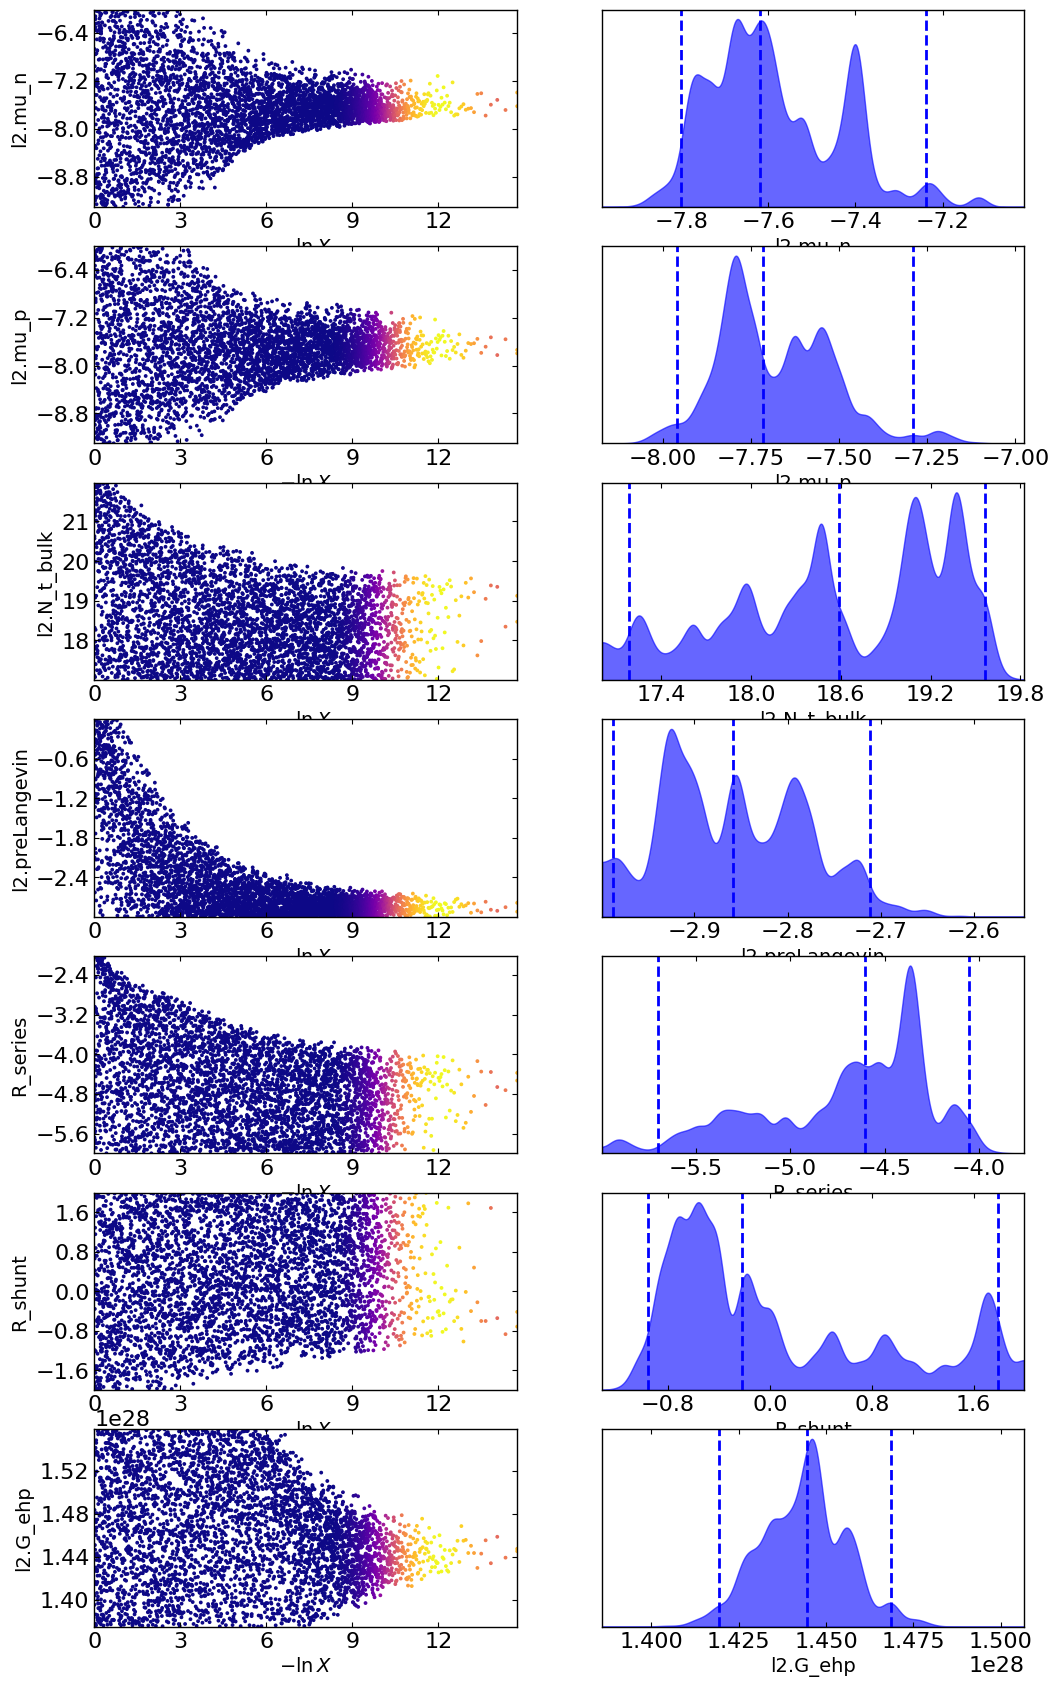

In [8]:
optimizer.sampler.plot_trace()

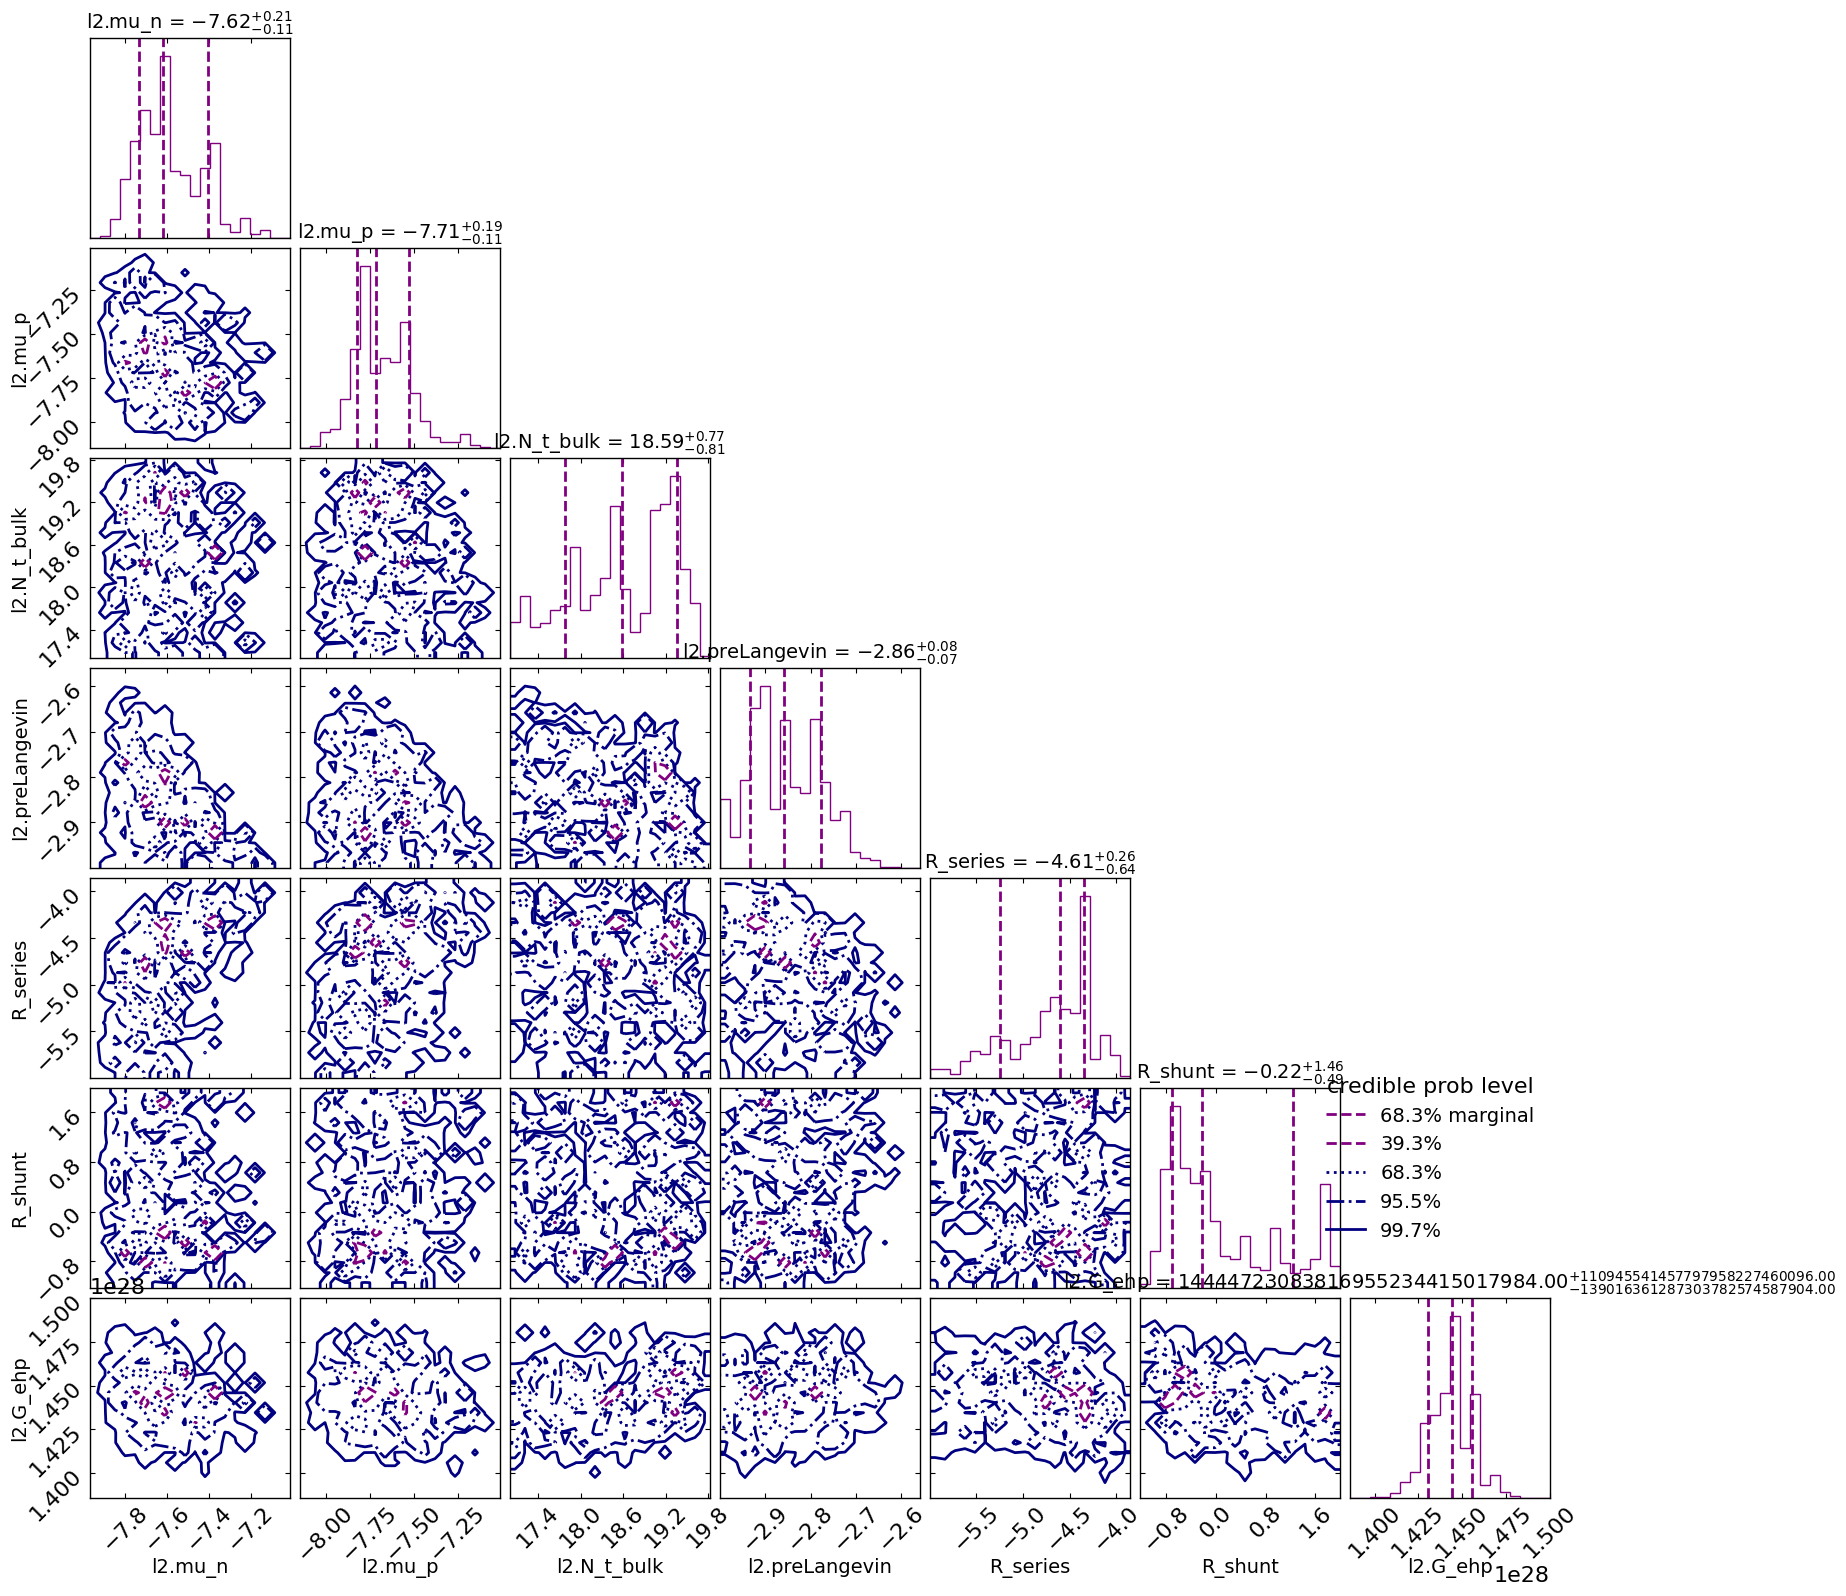

In [9]:
from ultranest.plot import cornerplot
plot = cornerplot(optimizer.nested_result)

{'JV_JV_mse_linear': 2.4411363939352615}


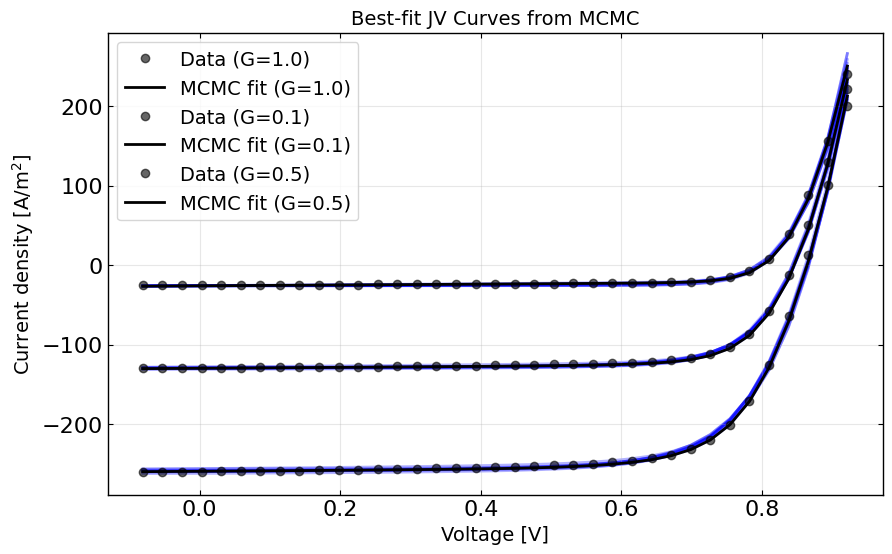

In [10]:
# Run simulation with best-fit parameters
best_fit_params = copy.deepcopy(optimizer.params)

# Create agent with best-fit parameters
best_agent = JVAgent(best_fit_params, X, y, session_path, simulation_setup, 
                     parallel=True, max_jobs=3, metric=metric, loss=loss)

best_fit_y = best_agent.run(parameters={})
print(jv.run_Ax(parameters={}))
# Plot the best-fit curves against data
plt.figure(figsize=(10, 6))
for Gfrac in Gfracs:
    mask = X[:,1] == Gfrac
    plt.plot(X[mask,0], y[mask], 'ko', alpha=0.6, label=f'Data (G={Gfrac})')
    plt.plot(X[mask,0], best_fit_y[mask], 'k-', label=f'MCMC fit (G={Gfrac})')

# add the 10 best fit curves
for i in range(10):
    # prep dum dic
    dum_dic = {}
    # add the parameters
    idx = 0
    for param in params:
        if param.type != 'fixed':
            dum_dic[param.name] = optimizer.flat_samples[i][idx]
            idx += 1
  
    y_ = best_agent.run(parameters=dum_dic)
    for Gfrac in Gfracs:
        mask = X[:,1] == Gfrac
        plt.plot(X[mask,0], y_[mask], 'b-', alpha=0.3, zorder = -1)

plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A/m$^2$]')
plt.legend()
plt.title('Best-fit JV Curves from MCMC')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# rasie
raise Exception('stop')

Exception: stop

In [ ]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path)
sim.delete_folders('tmp',session_path)
# uncomment the following lines to delete specific files
sim.clean_up_output('ZnO',session_path)
sim.clean_up_output('ActiveLayer',session_path)
sim.clean_up_output('BM_HTL',session_path)
sim.clean_up_output('simulation_setup_fakeOPV',session_path)